# Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Uploading Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving customer_churn_dataset-testing-master.csv to customer_churn_dataset-testing-master (1).csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_dataset-training-master.csv to customer_churn_dataset-training-master.csv


# Loading dataset

In [ ]:
train_df = pd.read_csv("customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("customer_churn_dataset-testing-master.csv")

train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


# Data Understanding and Exploration

In [ ]:
print(train_df.info())
print(train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment

# Data Preprocessing

In [ ]:
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

# Encoding Categorical Variables

In [ ]:
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']

for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# Feature Selection

In [ ]:
X = train_df.drop(['CustomerID', 'Churn'], axis=1)
y = train_df['Churn']

X_test = test_df.drop(['CustomerID', 'Churn'], axis=1)
y_test = test_df['Churn']

# Feature Scaling

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

# Train-Test Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Traing - Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)

print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lr))

Logistic Regression Accuracy: 0.850431567366475


# Model Training - Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))

Random Forest Accuracy: 0.9997051050846689


# Final Prediction on Test Data

In [ ]:
y_final = rf.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_final))
print("\nClassification Report:\n", classification_report(y_test, y_final))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_final))

Final Test Accuracy: 0.5035728710348899

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374


Confusion Matrix:
 [[ 1965 31916]
 [   41 30452]]


# Feature importance Visualization

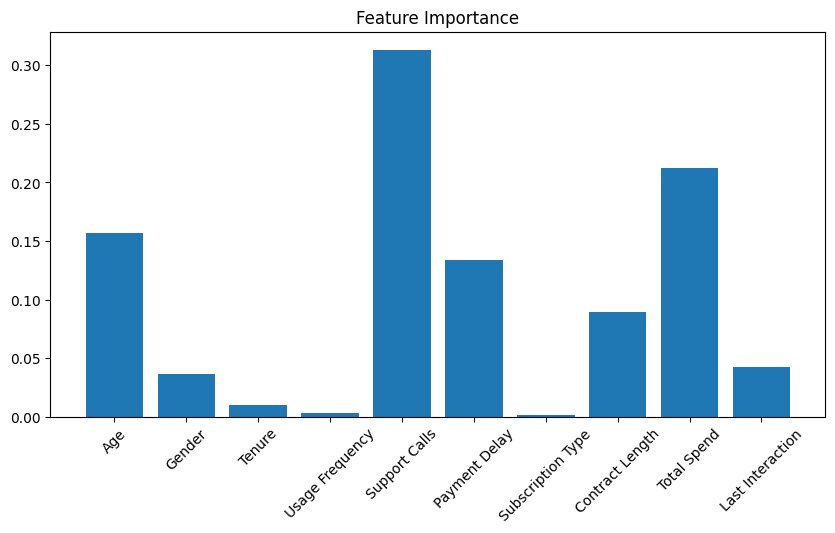

In [ ]:
features = train_df.drop(['CustomerID', 'Churn'], axis=1).columns
importance = rf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

